
## Minimum Norm Solution






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

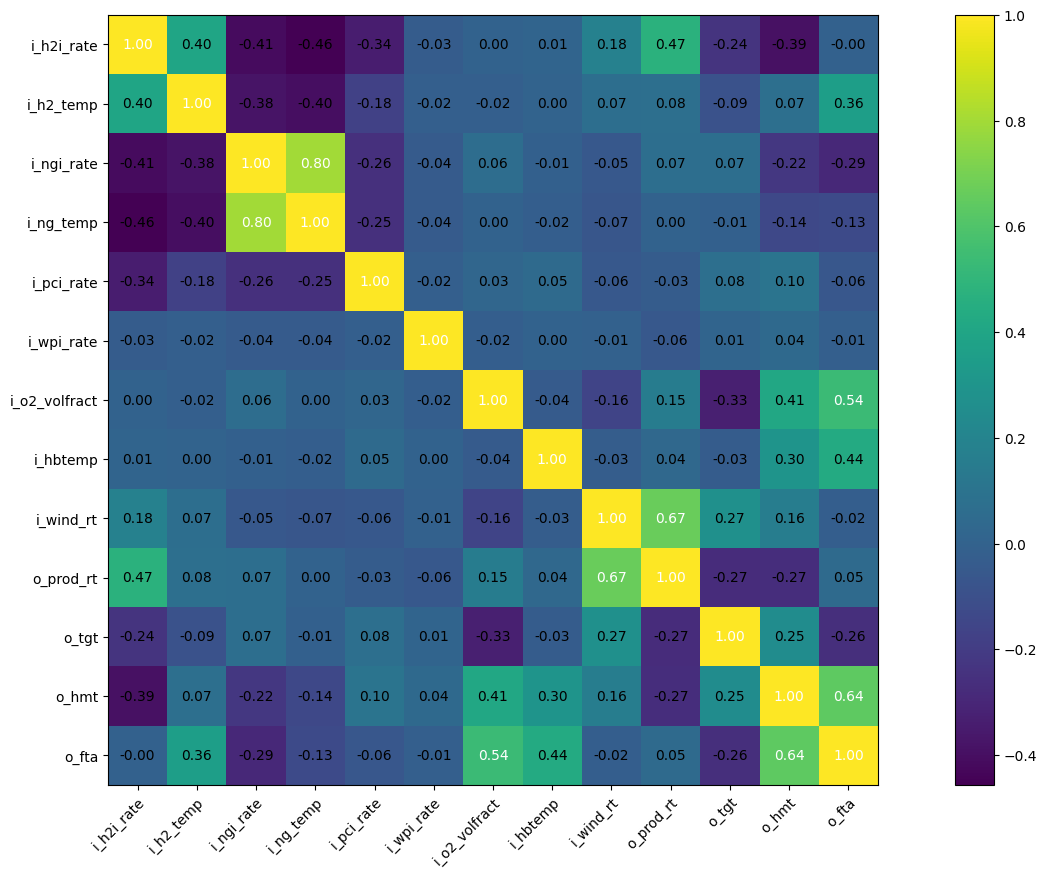

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
4


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 4)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 4)
(1000, 4)


In [17]:

from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca





In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 4)
(1000, 4)
(3999, 4)
(1000, 4)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 4     ## 7
n_outputs = 4




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 4     ## 7
n_outputs = 4





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 1.0763972997665405
100 ..... 0.9278478026390076
200 ..... 0.6582297086715698
300 ..... 0.7034969329833984
400 ..... 0.8753905892372131
500 ..... 0.7080339193344116
600 ..... 0.6127951145172119
700 ..... 1.243859052658081
800 ..... 0.7617237567901611
900 ..... 0.5755817294120789


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  98.1557, 1302.1492, 8429.1592, 2307.7764]])
y_deviations: tensor([[  50.7838,  524.0913, 1506.5802,  211.7870]])
x_means: tensor([[     0.0000,      0.0000,     -0.0000,     -0.0000]])
x_deviations: tensor([[272.1470, 157.0231,  51.3558,  36.0160]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.3719,  778.0579, 6922.5791, 2095.9895]])
tensor([[ 148.9395, 1826.2405, 9935.7393, 2519.5632]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[-272.1470, -157.0231,  -51.3558,  -36.0160]])
tensor([[272.1470, 157.0231,  51.3558,  36.0160]])



## Is model  invertible ?

* use the Jacobian


In [29]:

import torch
from torch.autograd.functional import jacobian


In [30]:

## x = torch.randn(1, 7, requires_grad=True)

x = torch.randn(      7, requires_grad=True)  # shape [7]

x = torch.randn(      4, requires_grad=True)  # shape [7]


In [31]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  # Only return 1 tensor to get a clean Jacobian




In [32]:

## J = jacobian(model_Forward, x)

J = jacobian(wrapped_model, x)


In [33]:

print( len(J) )


1


In [34]:


print( J.shape )  # Should be [1, 4, 7]


torch.Size([1, 4, 4])


In [35]:

u, s, v = torch.svd(J)  


In [36]:

rank = (s > 1e-5).sum()


In [37]:


print("Local Jacobian rank:", rank.item())


Local Jacobian rank: 4



## Example of Min Norm Solution



## Approach


In [38]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)


In [39]:


def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x







In [40]:



x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')



torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.65400388    0.66928555   94.32779014   25.98898396  289.66401996
 1222.18200507  196.74100624]
real
[  14.3162463     2.64200873   43.79187615   25.34053246  299.91034768
 1599.9732226   199.06597537]
1
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.828298      0.26355804   96.86104826   25.960134    217.31989406
 1231.40510499  196.64759907]
real
[   0.          149.38991869    0.           25.80215644  300.01129679
 1479.99356859  191.96386576]
2
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1,

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.2910748     0.56126842  104.45006293   26.12289284  357.55744887
 1194.65679427  195.93126987]
real
[  22.58348833    0.            0.           25.07773861  300.13056484
 1448.0933238   203.82560885]
43
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.49145221    0.18828152   90.85411522   26.01175155  331.79554445
 1183.30164821  197.1555445 ]
real
[  28.42124425    0.            0.           25.72811731 1200.03254314
 1199.92540427  203.66676627]
44
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.74887924    0.22794779   91.81271443   25.95629493  238.6278832
 1199.88233202  197.15932042]
real
[   9.22348719    0.           76.62966352   25.65103203  300.14464749
 1480.07304886  197.35636843]
64
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.68921809    0.91428322   83.65436888   25.94994148  334.96351302
 1199.81289809  197.60908992]
real
[  26.85295088    4.24799021    4.51748809   25.53899646 1200.02441268
 1600.14847053  200.63098214]
65
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.50036369    0.50334711   92.44803017   25.91434912  205.38124675
 1240.63393198  196.96824737]
real
[   9.25023346    1.71295252   71.82307415   25.63816154  299.94449506
 1479.9777616   197.3720998 ]
115
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   2.25696085    1.22813726  108.54738322   26.0919239   302.34551115
 1242.67885943  195.43467787]
real
[  13.44909778    5.145789     46.45161682   25.37288379  299.97382948
 1600.12356374  198.65770546]
116
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hb

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.4836788     0.92723886   85.66699477   26.03312812  383.10582789
 1143.39617776  197.60501884]
real
[   5.54138629    3.55378661   93.75848027   25.72587439  300.01865666
 1600.13508631  194.93684153]
136
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.85238712    0.32222626   98.13938335   26.01572307  267.15534797
 1206.40645039  196.56280555]
real
[   0.          171.06174184    0.           26.0866443   299.9763066
 1199.8579212   191.78922349]
137
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i

...

torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.4381058     0.68038046   83.65946827   25.92958251  293.82875402
 1195.54820221  197.7133764 ]
real
[  23.02859299    3.70839753    3.94811333   25.20524478  600.05196077
 1600.16492597  201.7192402 ]
842
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.76518028    0.52020929   90.50672488   25.92276664  208.85923337
 1211.79476295  197.24188036]
real
[   6.8204949    91.20247908    1.2681728    25.53439155  299.95566985
 1479.98501027  196.25883401]
843
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hb

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   3.06912284    0.33161765  104.74853546   26.03961341  294.42711808
 1262.61208679  195.73996714]
real
[  12.63178795    0.           57.91222486   25.42589698  299.93197505
 1599.85297193  198.27259689]
863
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.30767464    0.37716142   91.19299148   25.98058495  304.8717274
 1210.4565426   197.04262966]
real
[  13.9084343     0.           49.29806465   25.3664492   300.04970142
 1600.03230511  198.87200956]
864
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfrac

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.51441092    0.64716983   95.20479155   26.04475702  313.91757757
 1173.3316445   196.83942537]
real
[   0.61569332  125.07375728    0.06577457   25.89581951  299.99315033
 1200.00150025  194.96055584]
916
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.30421937    0.08291057   83.98891198   25.93091921  275.28280144
 1179.49513613  197.83173769]
real
[   1.18340893    0.          117.38289929   26.17160907  299.93446989
 1199.84713334  195.18624262]
917
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size

    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.73886558    0.89618386   84.52715662   26.04430023  398.51598901
 1127.62066678  197.74157742]
real
[   7.68518112    2.34853851   82.48458023   25.6340753   300.07290899
 1600.16406314  195.94452414]
936
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.14184707    0.51800224   88.48502087   26.05769264  394.15071357
 1144.68875265  197.38348412]
real
[   0.            0.          149.02312094   26.23765217  300.0162811
 1448.00048139  191.4384665 ]
937
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[ 

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.07270474    0.51247337   86.52430177   25.98936098  323.51045859
 1164.8896863   197.57481407]
real
[   9.16914528    1.66708442   71.75211831   25.66096167  299.94036249
 1447.98528595  197.51787347]
989
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   6.1479699     0.54737109   84.40670228   25.91265515  263.11778116
 1202.67875294  197.68366132]
real
[  13.06904878    2.59703006   43.75914905   25.63471084  299.92465394
 1199.98026094  200.77861433]
990
********************************
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size

In [41]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 340.3629



## Now add Costs


In [42]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_latent = pca.components_ @ price_real

price_latent = torch.tensor(price_latent, dtype=torch.float32)


In [43]:

def solve_minimum_norm_update( x0, target_y):
   
    
    # Ensure the input requires gradients

    x = x0.detach().clone().requires_grad_(True)
    

    # Compute the Jacobian matrix at the current input x
    # 'create_graph=True' is often needed if you want to backpropagate through this process
    
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    
    # Calculate the current residual (difference between desired and actual output)
    current_y = wrapped_model(x)
    delta_y   = target_y - current_y
    
    print( J.shape )
    
    # Flatten the Jacobian and residual if necessary (depends on problem dimensions)
    # This example assumes J is 2D and delta_y is 1D for simplicity
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
    # Compute the pseudoinverse of the Jacobian using SVD
    ####################################
    #J_pinv = torch.pinverse(J)
    
    thresholdSVD = 1e-2   ## 1e-2
    U, S, Vt = torch.linalg.svd(J)
    S_inv = torch.where(S > thresholdSVD, 1.0/S, torch.zeros_like(S))
    J_pinv = Vt.T @ torch.diag(S_inv) @ U.T

    
    ####################################
    
    # Calculate the minimum norm update: Delta x = J_pinv @ Delta y
    ## delta_x = J_pinv @ delta_y
    ##delta_x = 0.01 * (J_pinv @ delta_y)    ## 0.01
    
    lambda_cost = 0.01
    
    ##################################
       
    ## delta_x = (J_pinv @ delta_y) - lambda_cost * price_latent
    ## delta_x = 0.01 * delta_x
    
    
    rhs     = J.T @ delta_y - lambda_cost * price_latent
    delta_x = torch.linalg.solve(J.T @ J, rhs)
    delta_x = 0.01 * delta_x
    
   
    #################################

    
    # Reshape delta_x to match the original input shape
    delta_x = delta_x.view_as(x0)
    
    return delta_x






In [44]:


x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        # ---- compute cost at this iteration ----
        x_temp_np = x_temp.detach().numpy()
        x_temp_real = pca.inverse_transform(x_temp_np)

        # enforce physical constraint
        x_temp_real = np.maximum(x_temp_real, 0.0)

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
        print("real cost       :", cost_real)
        cost_diff    = cost - cost_real
        percent_diff = (cost - cost_real) / cost_real
        
    percent_diffs.append( percent_diff  )
          
    cost_diffs.append(       cost_diff  )
        
        
        
        
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')




torch.Size([1, 4, 4])
iteration 0 cost: 65.61809580312007...H2, PCI, NGI: [ 3.88942384  0.64666425 98.82747236]
real cost       : 81.80293199635425
torch.Size([1, 4, 4])
iteration 1 cost: 65.85323943998854...H2, PCI, NGI: [ 4.08050181  0.66038333 97.74169775]
real cost       : 81.80293199635425
torch.Size([1, 4, 4])
iteration 2 cost: 66.13150450551005...H2, PCI, NGI: [ 4.34577791  0.64149457 96.2137966 ]
real cost       : 81.80293199635425
torch.Size([1, 4, 4])
iteration 3 cost: 66.42184869438199...H2, PCI, NGI: [ 4.5969705   0.66030769 94.74731798]
real cost       : 81.80293199635425
torch.Size([1, 4, 4])
iteration 4 cost: 66.64158618057554...H2, PCI, NGI: [ 4.80194071  0.66907837 93.52948993]
real cost       : 81.80293199635425
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.80194071    0.66907837   93.52948993   25.98732243  292.88114864
 1218.55184393  196.81598546]
real
[  14.3162463     2.64200873   43.79187615   

torch.Size([1, 4, 4])
iteration 0 cost: 65.72176997995295...H2, PCI, NGI: [  3.48421493   0.68977044 102.19027968]
real cost       : 58.962649739485045
torch.Size([1, 4, 4])
iteration 1 cost: 66.15247822586822...H2, PCI, NGI: [  3.37601208   0.84688125 103.60309728]
real cost       : 58.962649739485045
torch.Size([1, 4, 4])
iteration 2 cost: 65.92218897740494...H2, PCI, NGI: [  2.91226766   0.93866703 106.66890266]
real cost       : 58.962649739485045
torch.Size([1, 4, 4])
iteration 3 cost: 65.50686849563367...H2, PCI, NGI: [  2.27113916   1.27953731 110.28554907]
real cost       : 58.962649739485045
torch.Size([1, 4, 4])
iteration 4 cost: 63.53820954302765...H2, PCI, NGI: [  0.78317216   1.39416392 118.02271401]
real cost       : 58.962649739485045
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.78317216    1.39416392  118.02271401   26.20669716  343.14403188
 1216.20580923  194.69723878]
real
[   0.            1.60689

torch.Size([1, 4, 4])
iteration 2 cost: 66.88923141775862...H2, PCI, NGI: [ 4.75287845  0.40836952 94.93869623]
real cost       : 58.59759192175363
torch.Size([1, 4, 4])
iteration 3 cost: 67.55139196232626...H2, PCI, NGI: [ 5.19239216  0.38163385 92.80037892]
real cost       : 58.59759192175363
torch.Size([1, 4, 4])
iteration 4 cost: 68.13113478972745...H2, PCI, NGI: [ 5.56291777  0.33293067 91.09306612]
real cost       : 58.59759192175363
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.56291777    0.33293067   91.09306612   26.03510087  356.8013204
 1173.51901812  197.12509853]
real
[   0.            0.          149.04474982   26.23788451  300.01795293
 1447.99827868  191.43569348]
50
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 65.63823909987855...H2, PCI, NGI: [ 4.05883623  0.48208777 97.84161278]
real cost       : 74.76991797158036
torch.Size([1, 4, 4])
iteration 1 cost: 65.36135121022022

torch.Size([1, 4, 4])
iteration 1 cost: 66.34024402277176...H2, PCI, NGI: [ 4.50492054  0.72776576 95.18559218]
real cost       : 112.62302935207005
torch.Size([1, 4, 4])
iteration 2 cost: 66.71391586869194...H2, PCI, NGI: [ 4.86856972  0.75096937 92.97733522]
real cost       : 112.62302935207005
torch.Size([1, 4, 4])
iteration 3 cost: 67.06822947933044...H2, PCI, NGI: [ 5.20126606  0.80203259 90.92226532]
real cost       : 112.62302935207005
torch.Size([1, 4, 4])
iteration 4 cost: 67.43776764666605...H2, PCI, NGI: [ 5.55361646  0.8505511  88.7455014 ]
real cost       : 112.62302935207005
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.55361646    0.8505511    88.7455014    25.94631062  285.35326541
 1220.33822705  197.19562124]
real
[  25.95357084    5.75388647    6.10971903   25.64682336 1199.96396568
 1480.12102209  200.89868097]
60
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 64.580476355

torch.Size([1, 4, 4])
iteration 4 cost: 65.85852367267712...H2, PCI, NGI: [ 4.4716767   0.50635003 94.93093372]
real cost       : 76.38614054818827
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   4.4716767     0.50635003   94.93093372   26.01628843  289.18816238
 1189.93230741  196.84286374]
real
[  13.95393888    0.05311979   41.03453049   25.60166254  299.85616461
 1199.83653479  201.19520315]
94
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 65.44707582110918...H2, PCI, NGI: [ 3.90785618  0.61010532 98.41109155]
real cost       : 81.43787544324445
torch.Size([1, 4, 4])
iteration 1 cost: 65.38815779215774...H2, PCI, NGI: [ 4.11512422  0.52075324 96.8138153 ]
real cost       : 81.43787544324445
torch.Size([1, 4, 4])
iteration 2 cost: 65.67752055342962...H2, PCI, NGI: [ 4.56890451  0.35344245 94.09692011]
real cost       : 81.43787544324445
torch.Size([1, 4, 4])
iteration 3 cost: 65.7402941350726

...

torch.Size([1, 4, 4])
iteration 2 cost: 63.67343218214342...H2, PCI, NGI: [  2.57432962   0.31451874 106.12318992]
real cost       : 147.8653773465479
torch.Size([1, 4, 4])
iteration 3 cost: 63.1341246565399...H2, PCI, NGI: [  2.18275329   0.26317522 108.27987257]
real cost       : 147.8653773465479
torch.Size([1, 4, 4])
iteration 4 cost: 62.70636726390407...H2, PCI, NGI: [  1.93328929   0.16845534 109.60950955]
real cost       : 147.8653773465479
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   1.93328929    0.16845534  109.60950955   26.06394499  252.91145814
 1248.12433598  195.48867759]
real
[   0.          171.1119507     0.           25.8810447   299.96862662
 1479.84991226  190.58649402]
929
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 64.96709651417981...H2, PCI, NGI: [  3.39699283   0.71668203 101.32488631]
real cost       : 76.94171101172014
torch.Size([1, 4, 4])
iteration 1 cost: 64.7

torch.Size([1, 4, 4])
iteration 4 cost: 66.74594053621868...H2, PCI, NGI: [ 5.63485236  0.02378003 88.36550212]
real cost       : 107.91683778128234
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.63485236    0.02378003   88.36550212   25.9426995   273.67632948
 1207.22743204  197.3651322 ]
real
[  27.88656155    0.            0.           25.74806242 1199.97048508
 1199.89231538  203.41623674]
939
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 65.39038468609087...H2, PCI, NGI: [  3.49942119   0.65998815 101.46542356]
real cost       : 87.45145740622358
torch.Size([1, 4, 4])
iteration 1 cost: 65.55007438188179...H2, PCI, NGI: [  3.45693384   0.65789087 102.12889633]
real cost       : 87.45145740622358
torch.Size([1, 4, 4])
iteration 2 cost: 65.72770023779293...H2, PCI, NGI: [  3.44006958   0.66118264 102.61247858]
real cost       : 87.45145740622358
torch.Size([1, 4, 4])
iteration 3 cost: 65.90

iteration 1 cost: 64.40989674463583...H2, PCI, NGI: [  2.74424514   0.64167772 105.58247692]
real cost       : 75.91763338553876
torch.Size([1, 4, 4])
iteration 2 cost: 63.62426334860794...H2, PCI, NGI: [  2.03168457   0.65898091 109.67708832]
real cost       : 75.91763338553876
torch.Size([1, 4, 4])
iteration 3 cost: 62.1936470350008...H2, PCI, NGI: [  0.779031     0.73104291 116.69296023]
real cost       : 75.91763338553876
torch.Size([1, 4, 4])
iteration 4 cost: 80.23382994704002...H2, PCI, NGI: [  0.          15.40678124 129.65409741]
real cost       : 75.91763338553876
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.           15.40678124  129.65409741   26.32855539  290.45035147
 1224.50552887  192.73330413]
real
[  12.46339469    0.           57.27587012   25.5064722   300.12288613
 1480.07292014  198.88084181]
975
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 65.42308542328954...H2, PC

torch.Size([1, 4, 4])
iteration 3 cost: 66.75772644209944...H2, PCI, NGI: [ 5.11271796  0.08257243 92.44856433]
real cost       : 55.10132654243735
torch.Size([1, 4, 4])
iteration 4 cost: 67.33806809744338...H2, PCI, NGI: [ 5.60232169  0.         89.85756269]
real cost       : 55.10132654243735
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.60232169    0.           89.85756269   25.99211104  315.68613858
 1186.23541833  197.26829343]
real
[   0.            0.          146.35952693   26.38786803  299.96293285
 1199.85282426  192.90646488]
984
********************************
torch.Size([1, 4, 4])
iteration 0 cost: 65.12201563442574...H2, PCI, NGI: [  3.35983643   0.58956422 102.1862114 ]
real cost       : 97.06564427503336
torch.Size([1, 4, 4])
iteration 1 cost: 65.0346836741922...H2, PCI, NGI: [  3.19995179   0.51919111 103.43137083]
real cost       : 97.06564427503336
torch.Size([1, 4, 4])
iteration 2 cost: 64.5796745

torch.Size([1, 4, 4])
iteration 0 cost: 65.71268049534845...H2, PCI, NGI: [ 3.95897252  0.59330852 98.56696383]
real cost       : 87.01175394287232
torch.Size([1, 4, 4])
iteration 1 cost: 66.27502456241281...H2, PCI, NGI: [ 4.40755795  0.51770513 96.25417529]
real cost       : 87.01175394287232
torch.Size([1, 4, 4])
iteration 2 cost: 66.51862344838632...H2, PCI, NGI: [ 4.69538017  0.33677647 94.80065258]
real cost       : 87.01175394287232
torch.Size([1, 4, 4])
iteration 3 cost: 66.90554116667123...H2, PCI, NGI: [ 5.02038765  0.28953159 93.06891799]
real cost       : 87.01175394287232
torch.Size([1, 4, 4])
iteration 4 cost: 67.4593631364234...H2, PCI, NGI: [ 5.48537186  0.23587378 90.56400381]
real cost       : 87.01175394287232
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   5.48537186    0.23587378   90.56400381   25.9961811   319.9785334
 1193.01252692  197.15374959]
real
[  22.57166027    0.            0.           25

In [45]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 351.71323


In [46]:

print("average cost diff:", np.mean(cost_diffs))

print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -21.062605793677392
average percent diff: -19.763977732672615 %


In [47]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)

print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 88.988988988989 % of cases
